<a href="https://colab.research.google.com/github/michaelsteven1299/proyecto_michael-/blob/main/src/03_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Diego Fernando Marin, 2024

# 03_EDA
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno se centra en comprender profundamente los datos mediante análisis estadístico y visualización. El EDA nos permite descubrir patrones, relaciones y características importantes en los datos.

**Propósito:** Obtener insights sobre los datos y preparar el terreno para la selección de características relevantes para el modelado.

**Tareas habituales:**
- Análisis univariante de variables
- Análisis de correlaciones
- Visualización de distribuciones
- Detección de patrones y tendencias
- Análisis de series temporales si aplica
- Identificación de relaciones entre variables
- Generación de hipótesis
- Documentación de insights importantes

**Cada sección debe tener**:
- La Pregunta que se realiza sobre los datos
- El código que genera las tablas o los gráficos donde encontramos la respuesta
- El código que da respuesta a dicha pregunta
- La interpretar del resultado
- Las conclusiones

In [1]:
# ============================================================
# CUADERNO EDA — Análisis Exploratorio
# ============================================================
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

TRUSTED_PATH = "/content/drive/MyDrive/proyecto_oro/data/trusted/"
df = pd.read_csv(TRUSTED_PATH + "oro_dxy_trusted.csv", parse_dates=['DATE'])

print(f"✅ Dataset cargado: {df.shape}")
df.head()

Mounted at /content/drive
✅ Dataset cargado: (1411, 34)


,DATE,bono_10y_Close,bono_10y_High,bono_10y_Low,bono_10y_Open,bono_10y_Volume,wti_crudo_Close,wti_crudo_High,wti_crudo_Low,wti_crudo_Open,...,vix_Close,vix_High,vix_Low,vix_Open,vix_Volume,oro_xauusd_Close,oro_xauusd_High,oro_xauusd_Low,oro_xauusd_Open,oro_xauusd_Volume
0,2021-01-04,0.917,0.953,0.907,0.935,0.0,47.619999,49.830002,47.180000,48.400002,...,26.969999,29.190001,22.559999,23.040001,0.0,1944.699951,1945.099976,1912.199951,1912.199951,154.0
1,2021-01-05,0.955,0.963,0.927,0.937,0.0,49.930000,50.200001,47.240002,47.380001,...,25.340000,28.600000,24.799999,26.940001,0.0,1952.699951,1952.699951,1941.300049,1941.699951,113.0
2,2021-01-06,1.042,1.054,1.000,1.000,0.0,50.630001,50.939999,49.480000,49.820000,...,25.070000,26.770000,22.139999,25.480000,0.0,1906.900024,1959.900024,1901.500000,1952.000000,331.0
3,2021-01-07,1.071,1.088,1.054,1.056,0.0,50.830002,51.279999,50.389999,50.529999,...,22.370001,23.910000,22.250000,23.670000,0.0,1912.300049,1926.699951,1912.000000,1922.599976,122.0
4,2021-01-08,1.105,1.126,1.075,1.088,0.0,52.240002,52.750000,50.810001,50.930000,...,21.559999,23.340000,21.420000,22.430000,0.0,1834.099976,1908.000000,1834.099976,1908.000000,60.0


In [2]:
# ============================================================
# 1. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================
print("📊 Estadísticas descriptivas — Precios Close:")
cols_close = [c for c in df.columns if 'Close' in c]
df[cols_close].describe().round(2)

📊 Estadísticas descriptivas — Precios Close:


,bono_10y_Close,wti_crudo_Close,plata_xagusd_Close,eur_usd_Close,dxy_Close,vix_Close,oro_xauusd_Close
count,1411.00,1411.00,1411.00,1411.00,1411.00,1411.00,1411.00
mean,3.44,76.71,31.85,1.11,100.81,19.31,2468.88
std,1.13,13.52,16.36,0.06,5.26,5.18,930.23
min,0.92,47.62,17.55,0.96,89.44,11.86,1623.30
25%,2.80,67.43,23.11,1.07,97.74,15.71,1821.40
50%,3.96,74.52,25.46,1.10,101.70,18.06,1982.10
75%,4.28,82.88,32.14,1.16,104.44,21.89,2768.00
max,4.99,123.70,115.08,1.23,114.11,52.33,5318.40


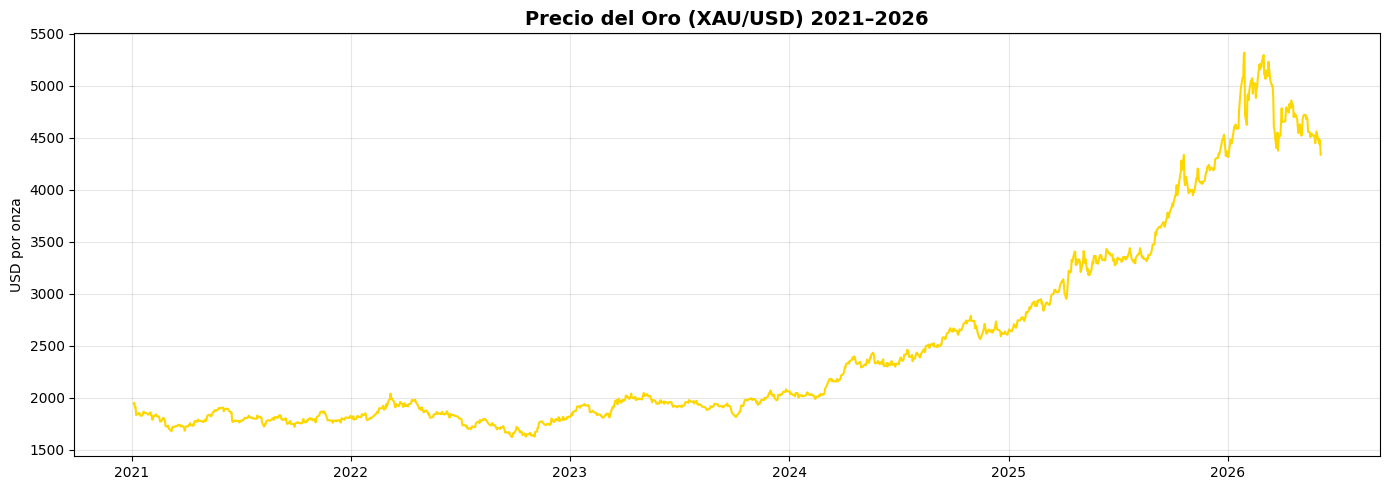

In [3]:
# ============================================================
# 2. EVOLUCIÓN DEL PRECIO DEL ORO
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['DATE'], df['oro_xauusd_Close'], color='gold', linewidth=1.5)
ax.set_title('Precio del Oro (XAU/USD) 2021–2026', fontsize=14, fontweight='bold')
ax.set_ylabel('USD por onza')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

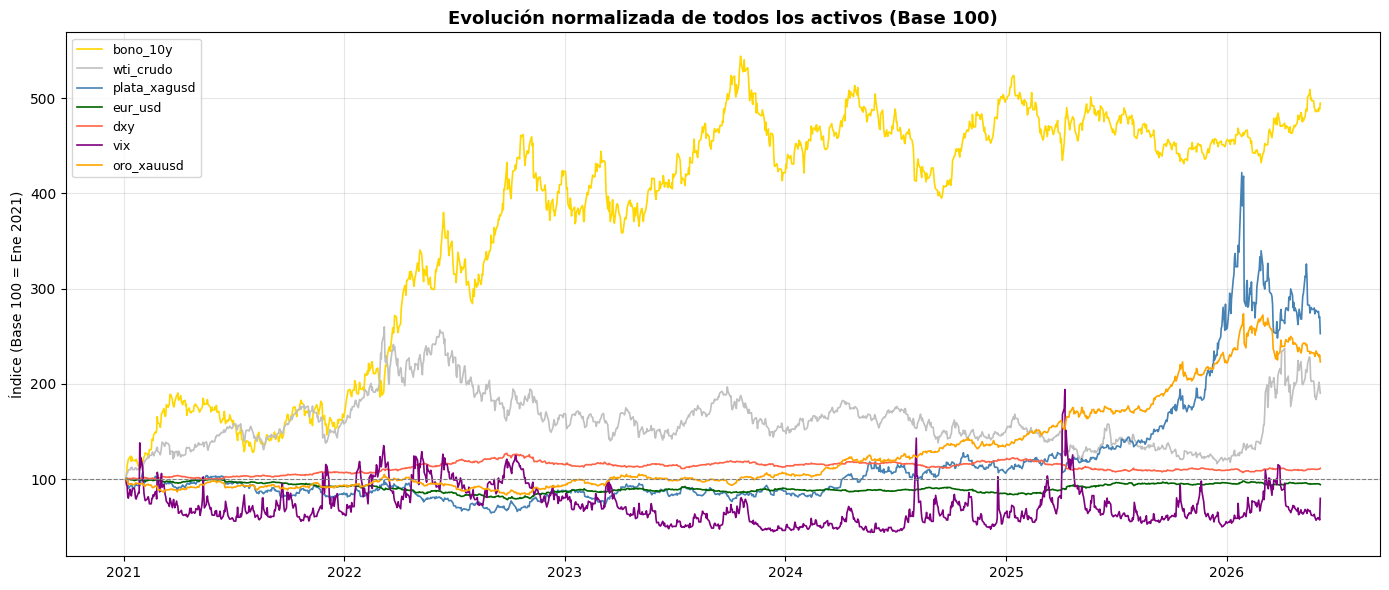

In [4]:
# ============================================================
# 3. TODOS LOS ACTIVOS — Evolución normalizada (base 100)
# ============================================================
cols_close = [c for c in df.columns if 'Close' in c]
df_norm = df[['DATE'] + cols_close].copy()

for col in cols_close:
    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
colores = ['gold', 'silver', 'steelblue', 'darkgreen', 'tomato', 'purple', 'orange']

for col, color in zip(cols_close, colores):
    ax.plot(df_norm['DATE'], df_norm[col], label=col.replace('_Close',''),
            linewidth=1.2, color=color)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Evolución normalizada de todos los activos (Base 100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Índice (Base 100 = Ene 2021)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

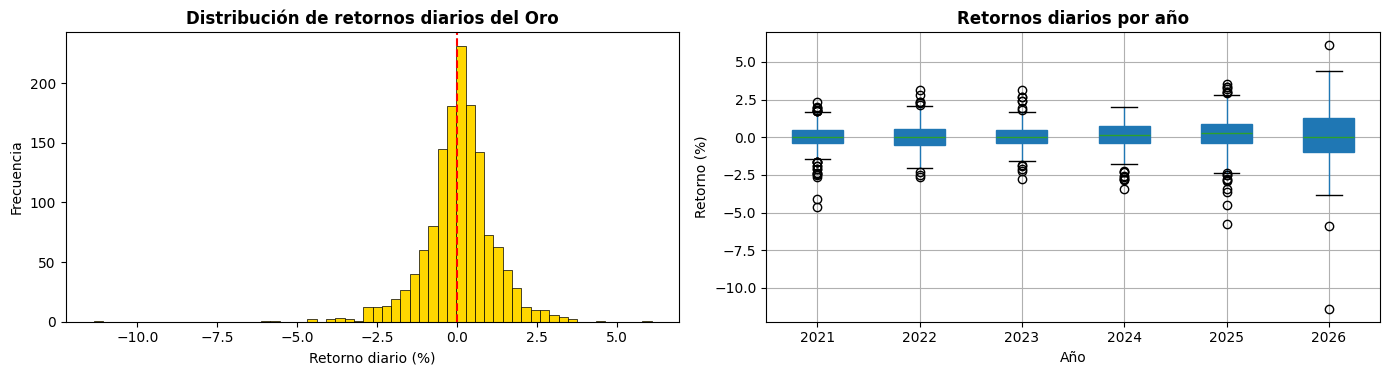

Retorno promedio diario: 0.0632%
Volatilidad diaria:      1.1208%
Retorno máximo:          6.0833%
Retorno mínimo:          -11.3662%


In [5]:
# ============================================================
# 4. DISTRIBUCIÓN DE RETORNOS DIARIOS DEL ORO
# ============================================================
df['oro_retorno_1d'] = df['oro_xauusd_Close'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma
axes[0].hist(df['oro_retorno_1d'].dropna(), bins=60, color='gold',
             edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribución de retornos diarios del Oro', fontweight='bold')
axes[0].set_xlabel('Retorno diario (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(0, color='red', linestyle='--')

# Boxplot por año
df['año'] = df['DATE'].dt.year
df.boxplot(column='oro_retorno_1d', by='año', ax=axes[1],
           patch_artist=True)
axes[1].set_title('Retornos diarios por año', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Retorno (%)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"Retorno promedio diario: {df['oro_retorno_1d'].mean():.4f}%")
print(f"Volatilidad diaria:      {df['oro_retorno_1d'].std():.4f}%")
print(f"Retorno máximo:          {df['oro_retorno_1d'].max():.4f}%")
print(f"Retorno mínimo:          {df['oro_retorno_1d'].min():.4f}%")

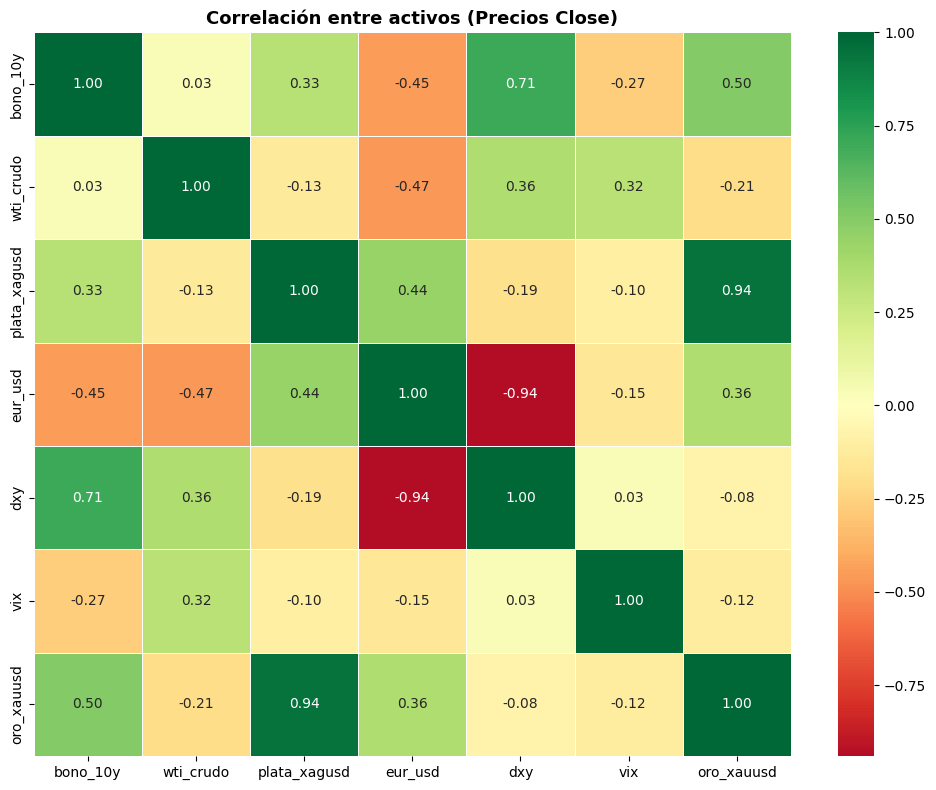

In [6]:
# ============================================================
# 5. CORRELACIÓN ENTRE ACTIVOS
# ============================================================
cols_close = [c for c in df.columns if 'Close' in c]
corr = df[cols_close].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            xticklabels=[c.replace('_Close','') for c in cols_close],
            yticklabels=[c.replace('_Close','') for c in cols_close])
ax.set_title('Correlación entre activos (Precios Close)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

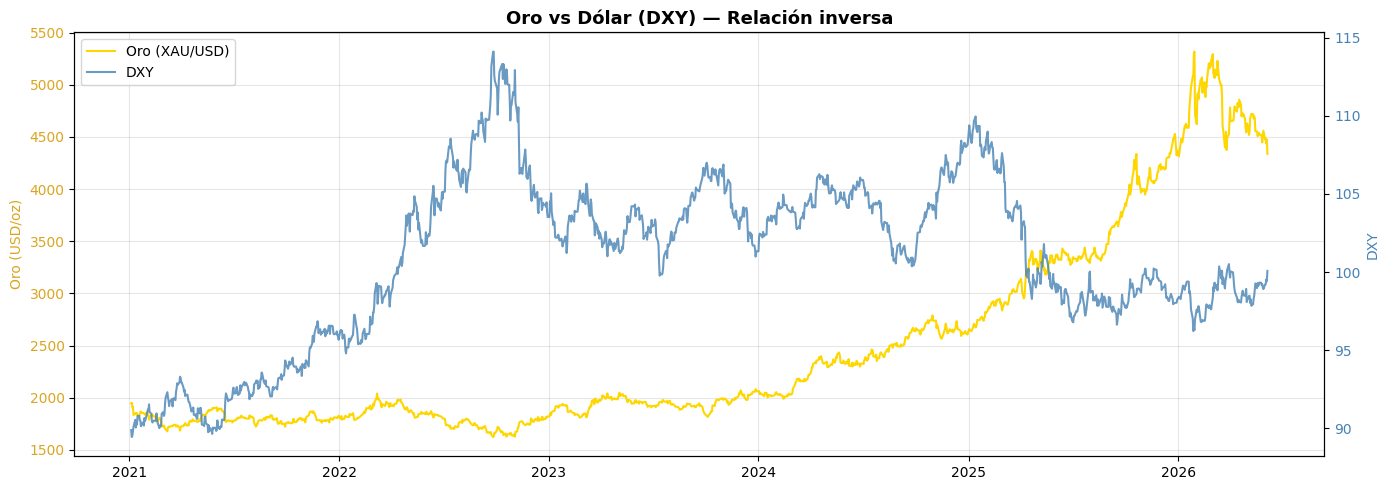

In [7]:
# ============================================================
# 6. ORO vs DXY — Relación inversa
# ============================================================
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df['DATE'], df['oro_xauusd_Close'], color='gold',
         linewidth=1.5, label='Oro (XAU/USD)')
ax1.set_ylabel('Oro (USD/oz)', color='goldenrod')
ax1.tick_params(axis='y', labelcolor='goldenrod')

ax2 = ax1.twinx()
ax2.plot(df['DATE'], df['dxy_Close'], color='steelblue',
         linewidth=1.5, label='DXY', alpha=0.8)
ax2.set_ylabel('DXY', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Oro vs Dólar (DXY) — Relación inversa', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

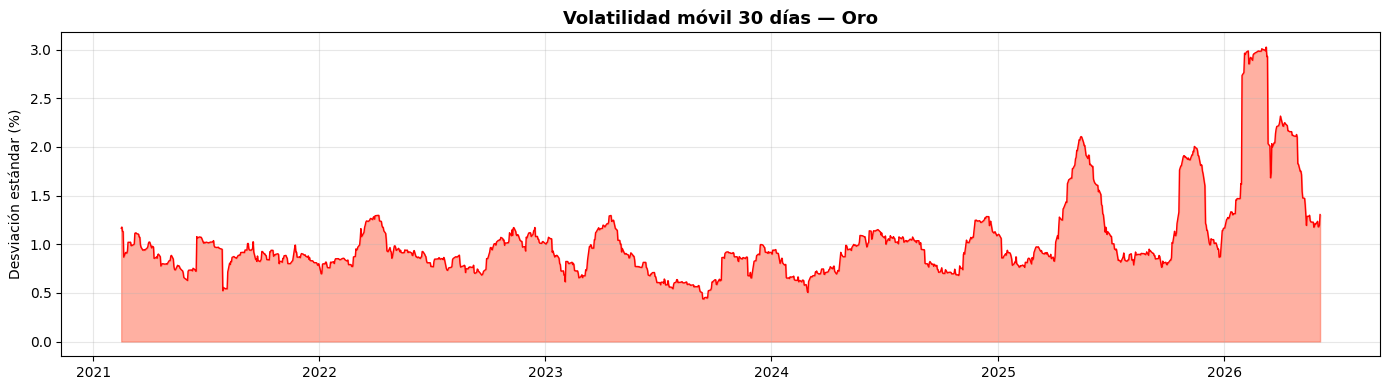

In [8]:
# ============================================================
# 7. VOLATILIDAD MÓVIL 30 DÍAS
# ============================================================
df['volatilidad_30d'] = df['oro_retorno_1d'].rolling(30).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df['DATE'], df['volatilidad_30d'],
                color='tomato', alpha=0.5, label='Volatilidad 30d')
ax.plot(df['DATE'], df['volatilidad_30d'], color='red', linewidth=1)
ax.set_title('Volatilidad móvil 30 días — Oro', fontsize=13, fontweight='bold')
ax.set_ylabel('Desviación estándar (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 8. RESUMEN FINAL DEL EDA
# ============================================================
print("=" * 50)
print("RESUMEN EDA")
print("=" * 50)
print(f"Período:            {df['DATE'].min().date()} → {df['DATE'].max().date()}")
print(f"Días de mercado:    {len(df):,}")
print(f"Activos analizados: {len(cols_close)}")
print(f"\nPrecio oro mínimo:  ${df['oro_xauusd_Close'].min():,.0f}")
print(f"Precio oro máximo:  ${df['oro_xauusd_Close'].max():,.0f}")
print(f"Precio oro actual:  ${df['oro_xauusd_Close'].iloc[-1]:,.0f}")
print(f"\nCorrelación Oro-DXY:   {df['oro_xauusd_Close'].corr(df['dxy_Close']):.3f}")
print(f"Correlación Oro-Plata: {df['oro_xauusd_Close'].corr(df['plata_xagusd_Close']):.3f}")
print(f"Correlación Oro-VIX:   {df['oro_xauusd_Close'].corr(df['vix_Close']):.3f}")

RESUMEN EDA
Período:            2021-01-04 → 2026-06-05
Días de mercado:    1,411
Activos analizados: 7

Precio oro mínimo:  $1,623
Precio oro máximo:  $5,318
Precio oro actual:  $4,337

Correlación Oro-DXY:   -0.078
Correlación Oro-Plata: 0.936
Correlación Oro-VIX:   -0.117


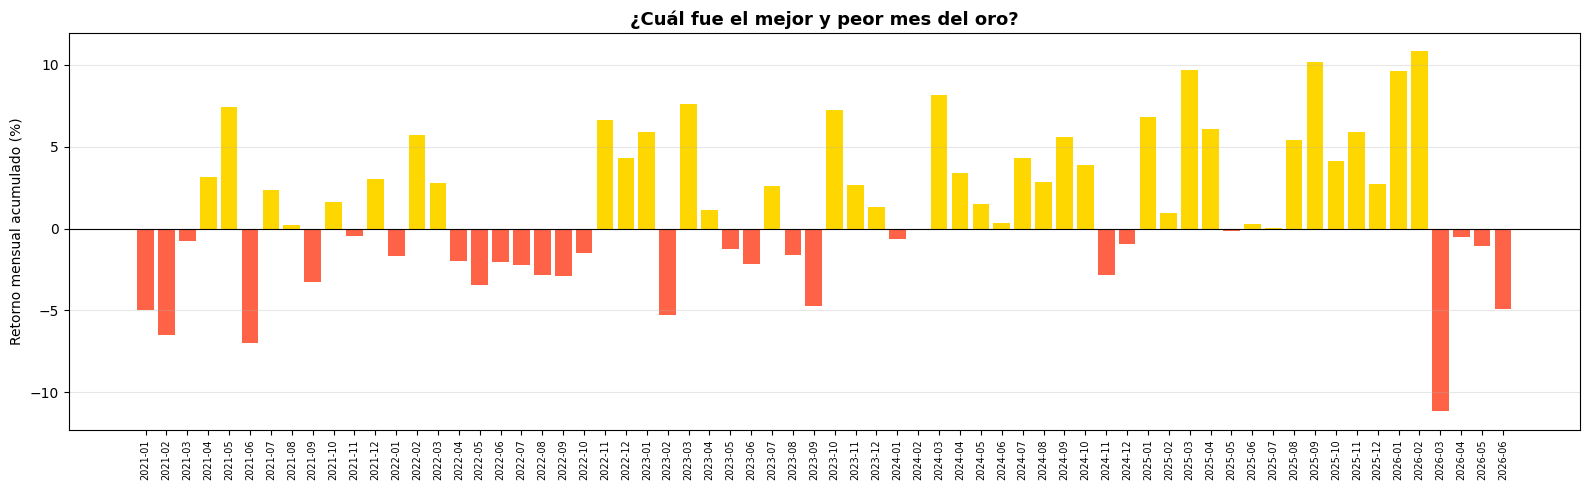

✅ Mejor mes: 2026-02 → 10.85%
❌ Peor mes:  2026-03  → -11.17%


In [10]:
# ============================================================
# EDA EXTENDIDO — Análisis con preguntas de negocio
# ============================================================

# ¿Cuál fue el mejor y peor mes del oro?
# ============================================================
df['mes_año'] = df['DATE'].dt.to_period('M')
retorno_mensual = df.groupby('mes_año')['oro_retorno_1d'].sum().reset_index()
retorno_mensual.columns = ['mes', 'retorno_mensual']

mejor_mes = retorno_mensual.loc[retorno_mensual['retorno_mensual'].idxmax()]
peor_mes  = retorno_mensual.loc[retorno_mensual['retorno_mensual'].idxmin()]

fig, ax = plt.subplots(figsize=(16, 5))
colores = ['tomato' if r < 0 else 'gold' for r in retorno_mensual['retorno_mensual']]
ax.bar(retorno_mensual['mes'].astype(str), retorno_mensual['retorno_mensual'], color=colores)
ax.set_title('¿Cuál fue el mejor y peor mes del oro?', fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno mensual acumulado (%)')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90, fontsize=7)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"✅ Mejor mes: {mejor_mes['mes']} → {mejor_mes['retorno_mensual']:.2f}%")
print(f"❌ Peor mes:  {peor_mes['mes']}  → {peor_mes['retorno_mensual']:.2f}%")

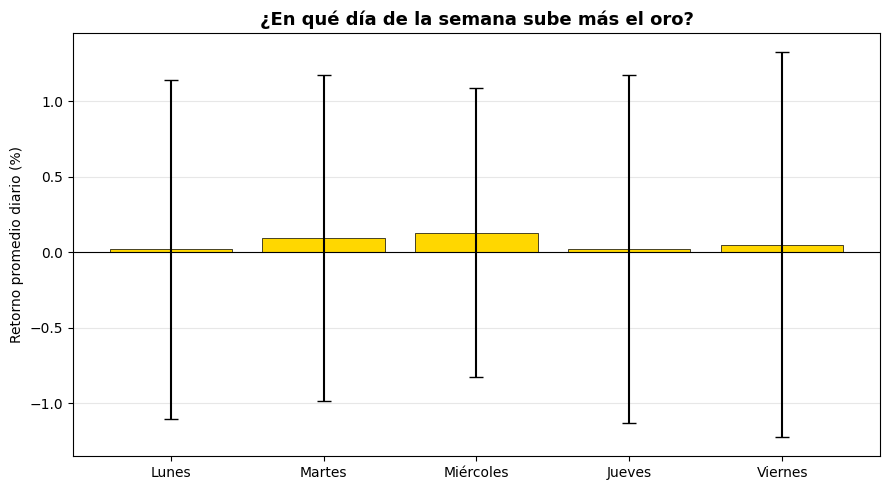

              mean     std
dia_semana                
Lunes       0.0206  1.1229
Martes      0.0922  1.0788
Miércoles   0.1301  0.9554
Jueves      0.0220  1.1528
Viernes     0.0510  1.2744


In [11]:
# ¿En qué día de la semana sube más el oro?
# ============================================================
dias = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes'}
df['dia_semana'] = df['DATE'].dt.dayofweek.map(dias)

retorno_dia = df.groupby('dia_semana')['oro_retorno_1d'].agg(['mean','std']).reindex(
    ['Lunes','Martes','Miércoles','Jueves','Viernes'])

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['gold' if v > 0 else 'tomato' for v in retorno_dia['mean']]
bars = ax.bar(retorno_dia.index, retorno_dia['mean'], color=colores,
              yerr=retorno_dia['std'], capsize=5, edgecolor='black', linewidth=0.5)
ax.set_title('¿En qué día de la semana sube más el oro?', fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno promedio diario (%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(retorno_dia.round(4))

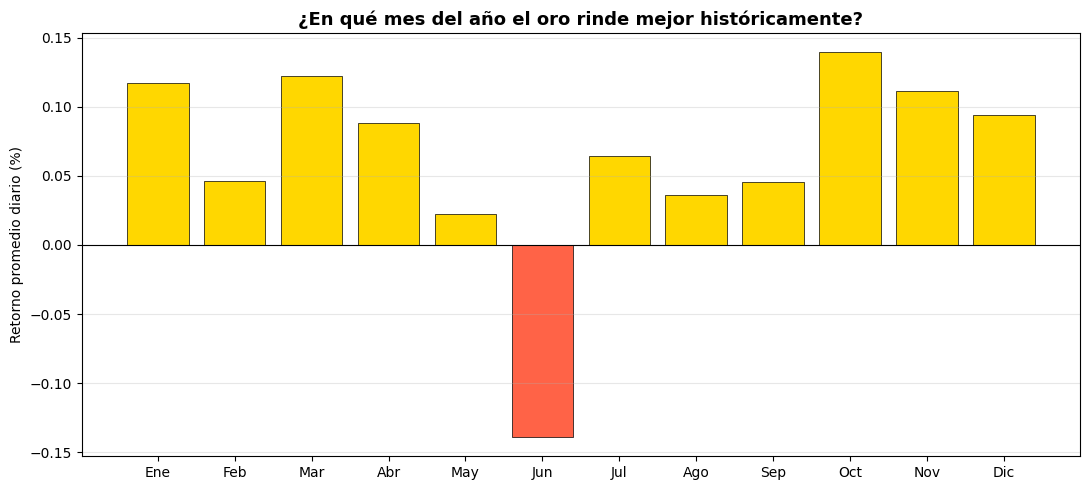

In [12]:
# ¿En qué mes del año el oro rinde mejor históricamente?
# ============================================================
meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
         7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
df['mes_num'] = df['DATE'].dt.month
df['mes_nombre'] = df['mes_num'].map(meses)

retorno_mes = df.groupby('mes_num')['oro_retorno_1d'].mean()
retorno_mes.index = retorno_mes.index.map(meses)

fig, ax = plt.subplots(figsize=(11, 5))
colores = ['gold' if v > 0 else 'tomato' for v in retorno_mes]
ax.bar(retorno_mes.index, retorno_mes, color=colores, edgecolor='black', linewidth=0.5)
ax.set_title('¿En qué mes del año el oro rinde mejor históricamente?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno promedio diario (%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

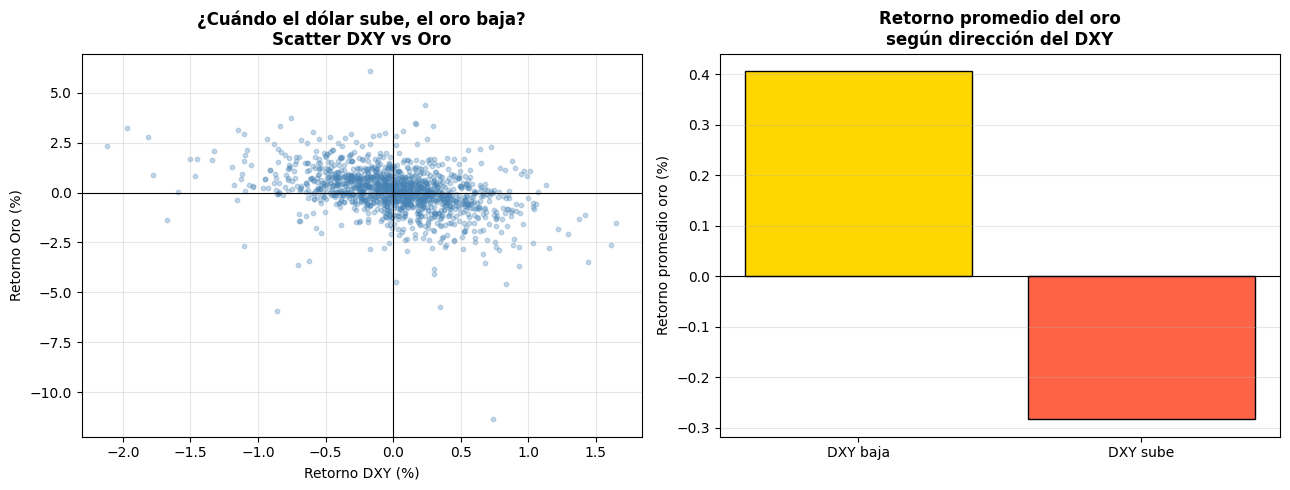

Correlación DXY vs Oro: -0.394
Retorno oro cuando DXY sube: -0.2831%
Retorno oro cuando DXY baja: 0.4066%


In [13]:
# ¿Cuándo el dólar sube, el oro baja?
# ============================================================
df['dxy_retorno'] = df['dxy_Close'].pct_change() * 100
df['dxy_sube']    = df['dxy_retorno'] > 0

retorno_oro_vs_dxy = df.groupby('dxy_sube')['oro_retorno_1d'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(df['dxy_retorno'], df['oro_retorno_1d'],
                alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Retorno DXY (%)')
axes[0].set_ylabel('Retorno Oro (%)')
axes[0].set_title('¿Cuándo el dólar sube, el oro baja?\nScatter DXY vs Oro', fontweight='bold')
axes[0].grid(alpha=0.3)

# Barras
etiquetas = ['DXY baja', 'DXY sube']
valores   = [retorno_oro_vs_dxy[False], retorno_oro_vs_dxy[True]]
colores   = ['gold', 'tomato']
axes[1].bar(etiquetas, valores, color=colores, edgecolor='black')
axes[1].set_title('Retorno promedio del oro\nsegún dirección del DXY', fontweight='bold')
axes[1].set_ylabel('Retorno promedio oro (%)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

corr = df['dxy_retorno'].corr(df['oro_retorno_1d'])
print(f"Correlación DXY vs Oro: {corr:.3f}")
print(f"Retorno oro cuando DXY sube: {retorno_oro_vs_dxy[True]:.4f}%")
print(f"Retorno oro cuando DXY baja: {retorno_oro_vs_dxy[False]:.4f}%")